In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


import os

#paths to train and validation image folders
train_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/train/images'
val_path = '/content/drive/MyDrive/ NEU-DET /NEU-DET/validation/images'

#getting class names from train folder
classes = sorted(os.listdir(train_path))

print("Dataset structure confirmed:")
print(f"Classes: {classes}")
print(f"\nTraining images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nValidation images per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(val_path, cls)))
    print(f"  {cls}: {count} images")

print(f"\nTotal training images: {240 * 6}")
print(f"Total validation images: {60 * 6}")
print(f"Train/val split: 80/20")

Mounted at /content/drive
Dataset structure confirmed:
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Training images per class:
  crazing: 240 images
  inclusion: 240 images
  patches: 240 images
  pitted_surface: 240 images
  rolled-in_scale: 240 images
  scratches: 240 images

Validation images per class:
  crazing: 60 images
  inclusion: 60 images
  patches: 60 images
  pitted_surface: 60 images
  rolled-in_scale: 60 images
  scratches: 60 images

Total training images: 1440
Total validation images: 360
Train/val split: 80/20


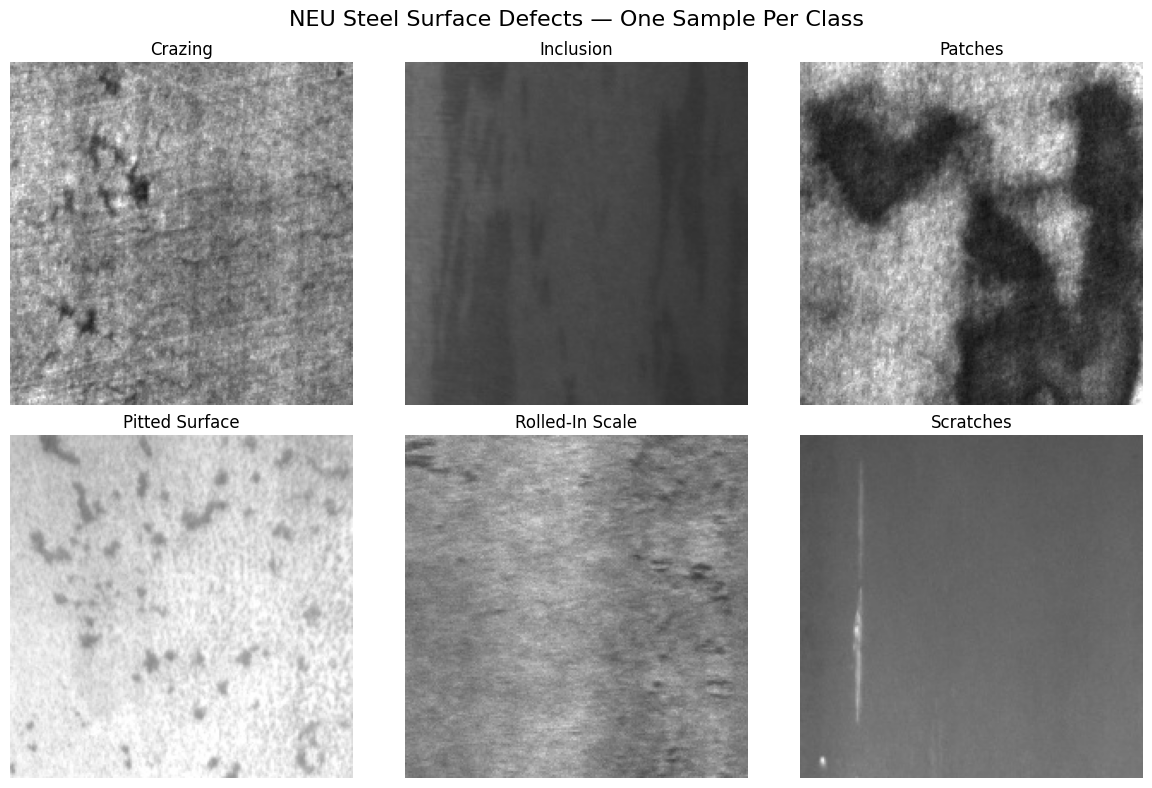

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#2 rows by 3 columns grid, one slot per defect class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('NEU Steel Surface Defects — One Sample Per Class', fontsize=16)

#loop through each defect class
for idx, cls in enumerate(classes):
    #path to this class folder
    cls_path = os.path.join(train_path, cls)

    #need one representative image from each class
    img_file = os.listdir(cls_path)[0]

    #full path to that image file
    img_path = os.path.join(cls_path, img_file)

    #load the image from file
    img = mpimg.imread(img_path)

    #idx 0,1,2 go in row 0 — idx 3,4,5 go in row 1
    #// gives the row, % gives the column
    row = idx // 3
    col = idx % 3

    #display in grayscale, steel images are black and white
    #without this matplotlib shows grayscale images in weird colors
    axes[row][col].imshow(img, cmap='gray')

    #use class name as title, replaced underscore with space for readability
    axes[row][col].set_title(cls.replace('_', ' ').title(), fontsize=12)
    axes[row][col].axis('off')

plt.tight_layout()
#save for readme
plt.savefig('defect_samples.png', dpi=150)
plt.show()

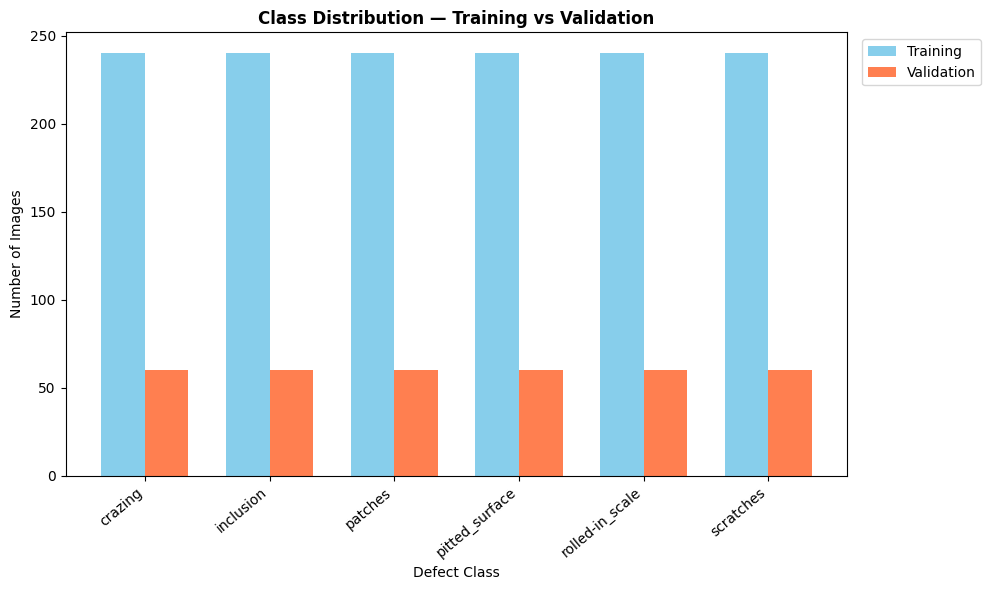

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#prepare data
categories = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Training = [240, 240, 240, 240, 240, 240]
Validation = [60, 60, 60, 60, 60, 60]

#set bar positions and width
x = np.arange(len(categories))
width = 0.35

#create figure
fig, ax = plt.subplots(figsize=(10, 6))

#plot two sets of bars side by side
rects1 = ax.bar(x - width/2, Training, width, label='Training', color='skyblue')
rects2 = ax.bar(x + width/2, Validation, width, label='Validation', color='coral')


ax.set_title('Class Distribution — Training vs Validation', fontweight='bold')
ax.set_xlabel('Defect Class')
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=40, ha='right')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1))

plt.tight_layout()
#save for the readme
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#training transforms, includes augmentation to reduce overfitting
#augmentation creates variations of each image so model sees different versions each epoch
transform_train = transforms.Compose([
    #resize from 200x200 to 224x224 as resnet18 expects exactly 224x224
    transforms.Resize((224, 224)),
    #convert grayscale to 3 channels as resnet18 expects RGB not grayscale
    transforms.Grayscale(num_output_channels=3),
    #randomly flip horizontally, a flipped defect is still the same defect
    #doubles the variety of images the model sees
    transforms.RandomHorizontalFlip(),
    #randomly rotate up to 10 degrees, adds variation without distorting defects
    transforms.RandomRotation(10),
    #from PIL image to pytorch tensor so the model can process it
    transforms.ToTensor(),
    #resnet18 was trained on ImageNet with these exact normalization values
    #images normalized the same way or transfer learning breaks
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#validation transforms — no augmentation, just resize and normalize
#consistent evaluation needed, no random changes during testing
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#load training dataset using ImageFolder
#ImageFolder automatically assigns class labels based on subfolder names(carzing folder = class 0, for instance)
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=transform_train
)

#load validation dataset
val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=transform_val
)

#created dataloaders to feeds images in batches of 32 during training, cant feed all 1440 at once
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

#not shuffling validation as order doesnt affect accuracy measurement(unlike I did with train data)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2 #got 2 cpu CPU cores load images in parallel while GPU trains
)

#to confirm everything loaded correctly
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index mapping: {train_dataset.class_to_idx}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training images: 1440
Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class to index mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Training batches: 45
Validation batches: 12


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
from PIL import Image

print("Extracting features for baseline classifier...")

def extract_features(data_path, classes, target_size=(64, 64)):
    features = []
    labels = []

    for label_idx, cls in enumerate(classes):
        cls_path = os.path.join(data_path, cls)

        for img_file in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_file)

            #open image, resize to 64x64, convert to grayscale(defects are about texture not color)
            img = Image.open(img_path).convert('L')
            #resize to 64x64 — small enough to train fast, big enough to capture patterns
            img = img.resize(target_size)

            #flatten to 1D vector — 64x64 = 4096 numbers per image
            img_array = np.array(img).flatten()

            #normalize pixel values to 0-1(keeps the math stable during training)
            img_array = img_array / 255.0

            features.append(img_array)
            labels.append(label_idx)

    return np.array(features), np.array(labels)

#extract features from training and validation sets
print("Extracting training features...")
X_train, y_train = extract_features(train_path, classes)

print("Extracting validation features...")
X_val, y_val = extract_features(val_path, classes)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

#train logistic regression
print("\nTraining logistic regression baseline...")
lr_model = LogisticRegression(
    max_iter=1000, #give it enough iterations to find good weights
    random_state=42, #same result every time I run it
    C=1.0 #standard regularization to prevent overfitting
)
lr_model.fit(X_train, y_train)

#evaluate on validation set
y_pred = lr_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_pred) * 100

print(f"\nBaseline Logistic Regression Accuracy: {baseline_accuracy:.1f}%")
print(f"This will be compared against ResNet18 transfer learning")

Extracting features for baseline classifier...
Extracting training features...
Extracting validation features...

Training features shape: (1440, 4096)
Validation features shape: (360, 4096)

Training logistic regression baseline...

Baseline Logistic Regression Accuracy: 41.4%
This will be compared against ResNet18 transfer learning


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

#load pretrained ResNet18, already knows how to detect edges textures and shapes
model = models.resnet18(pretrained=True)

#freeze all layers, not going to change the weights that were learned from ImageNet
for param in model.parameters():
    param.requires_grad = False

#replace the final layer — original outputs 1000 ImageNet classes
#new layer outputs 6 steel defect classes
#this new layer starts with random weights — it will be trained on my data
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 6)
)

#move model to GPU as its much faster than cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

#only train the parameters in the final layer, all other layers are frozen
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

#cross entropy loss, measures how wrong predictions are
criterion = nn.CrossEntropyLoss()

#reduce learning rate every 5 epochs, helps model converge precisely later
#big steps early to learn fast, small steps later to fine-tune precisely
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Model ready on: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


Model ready on: cuda
Trainable parameters: 3,078
Total parameters: 11,179,590


In [ ]:
#lists to track progress
train_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
best_epoch = 0

print("Starting ResNet18 training...")
print("-" * 60)

for epoch in range(15):

    #training mode turns dropout on
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        #send batch to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        #clear gradients from previous batch to not pile up
        optimizer.zero_grad()

        #run images through model
        outputs = model(inputs)

        #how wrong were the predictions
        loss = criterion(outputs, labels)

        #backpropagation, calculate gradients to figure out what to fix
        loss.backward()

        #update weights
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    #evaluation mode turns dropout off for consistent results
    model.eval()
    correct = 0
    total = 0

    #no need to track gradients when just checking performance
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = 100. * correct / total

    #save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')

    #reduce learning rate on schedule
    scheduler.step()

    #store results for charts later
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/15 | "
          f"Loss: {avg_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Val: {val_acc:.1f}%"
          + (" ← best" if val_acc == best_val_acc else ""))

print("-" * 60)
print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")

Starting ResNet18 training...
------------------------------------------------------------
Epoch  1/15 | Loss: 1.210 | Train: 58.1% | Val: 81.4% ← best
Epoch  2/15 | Loss: 0.477 | Train: 89.9% | Val: 89.7% ← best
Epoch  3/15 | Loss: 0.298 | Train: 94.9% | Val: 86.7%
Epoch  4/15 | Loss: 0.239 | Train: 95.4% | Val: 88.1%
Epoch  5/15 | Loss: 0.208 | Train: 94.9% | Val: 91.9% ← best
Epoch  6/15 | Loss: 0.192 | Train: 95.5% | Val: 93.1% ← best
Epoch  7/15 | Loss: 0.180 | Train: 95.3% | Val: 92.8%
Epoch  8/15 | Loss: 0.160 | Train: 96.2% | Val: 91.4%
Epoch  9/15 | Loss: 0.156 | Train: 96.1% | Val: 95.6% ← best
Epoch 10/15 | Loss: 0.148 | Train: 96.6% | Val: 95.6% ← best
Epoch 11/15 | Loss: 0.154 | Train: 95.8% | Val: 94.7%
Epoch 12/15 | Loss: 0.139 | Train: 96.7% | Val: 95.6% ← best
Epoch 13/15 | Loss: 0.137 | Train: 96.5% | Val: 93.9%
Epoch 14/15 | Loss: 0.128 | Train: 96.8% | Val: 94.7%
Epoch 15/15 | Loss: 0.133 | Train: 96.6% | Val: 94.4%
--------------------------------------------------

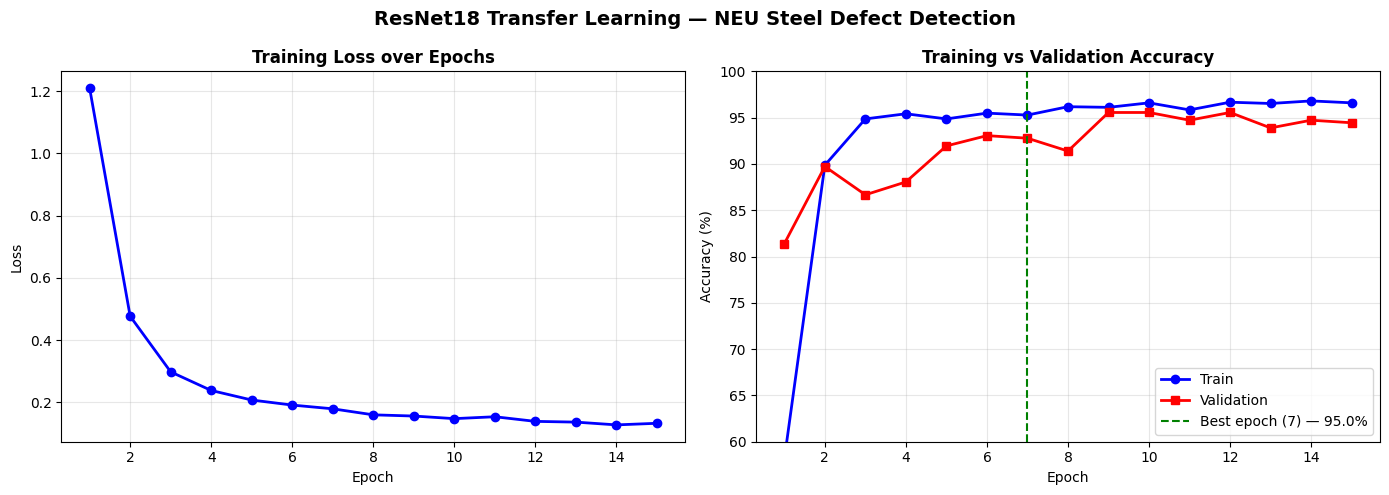

Best validation accuracy: 95.6% at epoch 9
Logistic Regression baseline: 41.4%
Improvement: 54.2 percentage points


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#two charts side by side — loss on the left, accuracy on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#left chart, training loss going down over epochs
ax1.plot(range(1, 16), train_losses,
         color='blue', marker='o', linewidth=2)
ax1.set_title('Training Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

#right chart : train vs validation accuracy
#gap between lines shows overfitting
ax2.plot(range(1, 16), train_accs,
         color='blue', marker='o', label='Train', linewidth=2)
ax2.plot(range(1, 16), val_accs,
         color='red', marker='s', label='Validation', linewidth=2)

#marking where the best model was saved with a vertical line
ax2.axvline(x=7, color='green', linestyle='--',
            label=f'Best epoch (7) — 95.0%')

ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(60, 100)

plt.suptitle('ResNet18 Transfer Learning — NEU Steel Defect Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
#saving for readme
plt.savefig('resnet18_training.png', dpi=150)
plt.show()

print(f"Best validation accuracy: {best_val_acc:.1f}% at epoch {best_epoch}")
print(f"Logistic Regression baseline: 41.4%")
print(f"Improvement: {best_val_acc - 41.4:.1f} percentage points")

#download the best model(need for Streamlit app later)
from google.colab import files
files.download('best_model.pth')

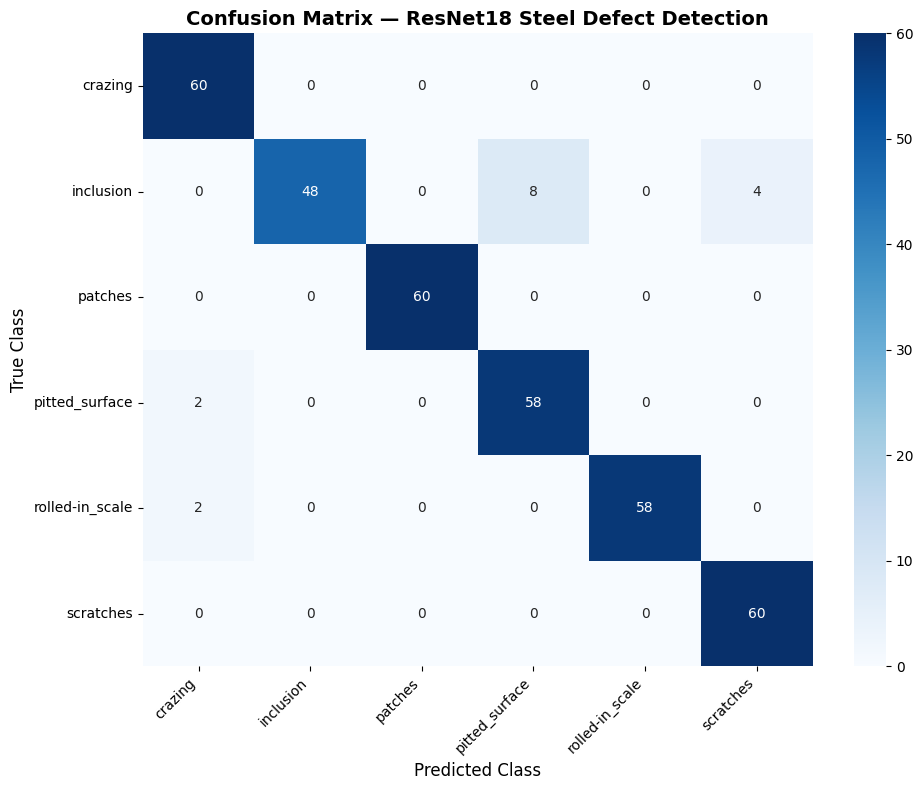


Per Class Performance:
--------------------------------------------------
crazing             : 60/60 = 100.0%
inclusion           : 48/60 = 80.0%
patches             : 60/60 = 100.0%
pitted_surface      : 58/60 = 96.7%
rolled-in_scale     : 58/60 = 96.7%
scratches           : 60/60 = 100.0%

Detailed Classification Report:
                 precision    recall  f1-score   support

        crazing       0.94      1.00      0.97        60
      inclusion       1.00      0.80      0.89        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.88      0.97      0.92        60
rolled-in_scale       1.00      0.97      0.98        60
      scratches       0.94      1.00      0.97        60

       accuracy                           0.96       360
      macro avg       0.96      0.96      0.95       360
   weighted avg       0.96      0.96      0.95       360



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax
)

ax.set_title('Confusion Matrix — ResNet18 Steel Defect Detection',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nPer Class Performance:")
print("-" * 50)
for i, cls in enumerate(classes):
    class_total = cm[i].sum()
    class_correct = cm[i][i]
    class_acc = 100 * class_correct / class_total
    print(f"{cls:20s}: {class_correct}/{class_total} = {class_acc:.1f}%")

print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

In [ ]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
for param in model.layer4.parameters():
    param.requires_grad = True

target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

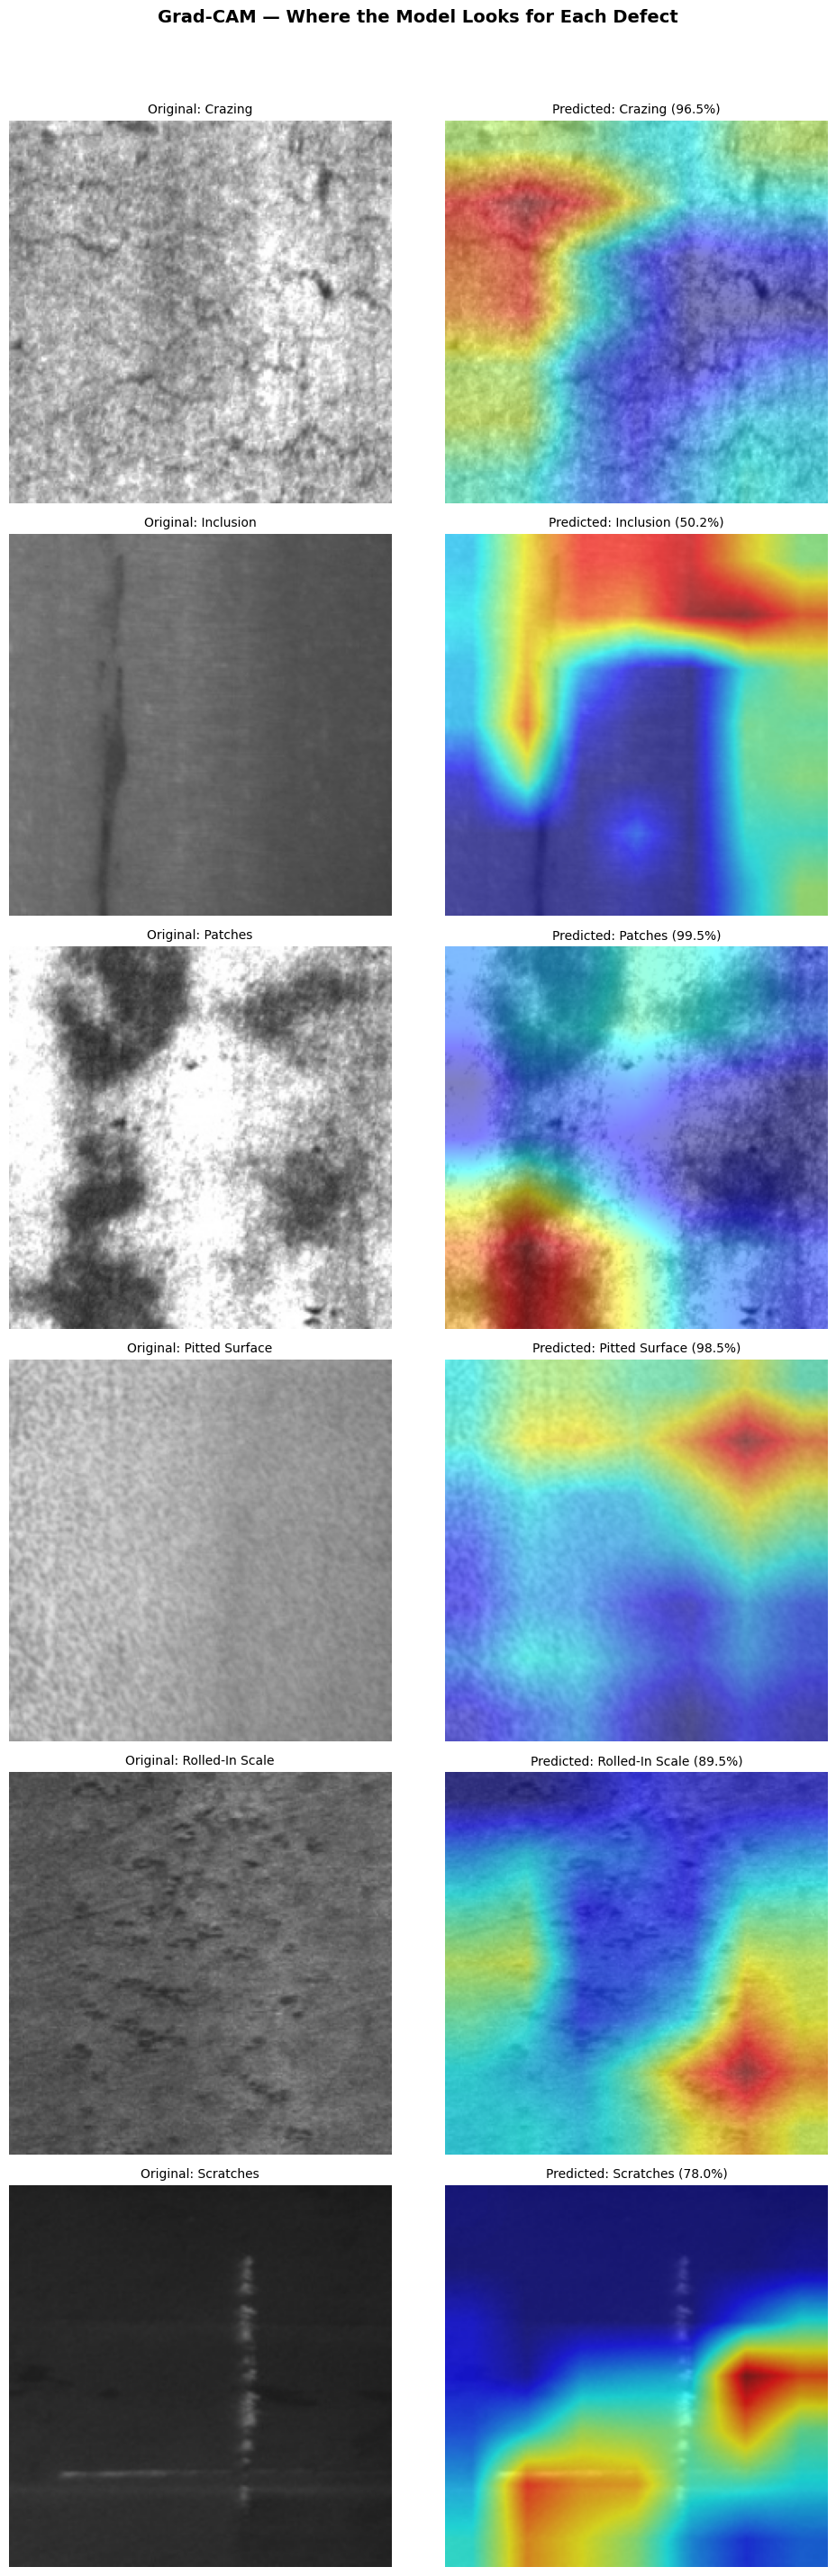

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
from PIL import Image

import subprocess
subprocess.run(['pip', 'install', 'grad-cam', '-q'])

target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

def get_gradcam(image_path, predicted_class_idx):
    img_pil = Image.open(image_path).convert('RGB')
    img_pil = img_pil.resize((224, 224))


    img_array = np.array(img_pil) / 255.0


    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img_original = Image.open(image_path).convert('L')
    input_tensor = transform(img_original).unsqueeze(0).to(device)

    targets = [ClassifierOutputTarget(predicted_class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]


    visualization = show_cam_on_image(
        img_array.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return visualization, grayscale_cam


fig, axes = plt.subplots(6, 2, figsize=(10, 28))
fig.suptitle('Grad-CAM — Where the Model Looks for Each Defect',
             fontsize=14, fontweight='bold', y=1.02)

for idx, cls in enumerate(classes):
    cls_path = os.path.join(val_path, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)


    img_pil = Image.open(img_path).convert('L')
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)

    predicted_class = classes[predicted_idx.item()]
    conf_pct = confidence.item() * 100


    gradcam_img, _ = get_gradcam(img_path, predicted_idx.item())


    original = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    axes[idx][0].imshow(original, cmap='gray')
    axes[idx][0].set_title(f'Original: {cls.replace("_", " ").title()}', fontsize=10)
    axes[idx][0].axis('off')


    axes[idx][1].imshow(gradcam_img)
    axes[idx][1].set_title(f'Predicted: {predicted_class.replace("_", " ").title()} ({conf_pct:.1f}%)', fontsize=10)
    axes[idx][1].axis('off')

plt.subplots_adjust(top=0.95)
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150)
plt.show()

In [ ]:
def predict_with_confidence(image_path, threshold=0.70):
    img_pil = Image.open(image_path).convert('L')

    from torchvision import transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)

    confidence_pct = confidence.item() * 100
    predicted_class = classes[predicted_idx.item()]
    all_probs = probs[0].tolist()

    if confidence_pct < threshold * 100:
        return {
            'status': 'low_confidence',
            'message': f'Low confidence ({confidence_pct:.1f}%) — recommend manual inspection',
            'predicted_class': predicted_class,
            'confidence': confidence_pct,
            'all_probabilities': {cls: prob * 100 for cls, prob in zip(classes, all_probs)}
        }
    else:
        return {
            'status': 'confident',
            'predicted_class': predicted_class,
            'confidence': confidence_pct,
            'all_probabilities': {cls: prob * 100 for cls, prob in zip(classes, all_probs)}
        }

print("Testing confidence rejection on sample images:")
print("-" * 60)

for cls in classes:
    cls_path = os.path.join(val_path, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)

    result = predict_with_confidence(img_path)

    if result['status'] == 'low_confidence':
        print(f"{cls:20s}: ⚠️  {result['message']}")
    else:
        print(f"{cls:20s}: ✅  {result['predicted_class']} ({result['confidence']:.1f}%)")

Testing confidence rejection on sample images:
------------------------------------------------------------
crazing             : ✅  crazing (96.5%)
inclusion           : ⚠️  Low confidence (50.2%) — recommend manual inspection
patches             : ✅  patches (99.5%)
pitted_surface      : ✅  pitted_surface (98.5%)
rolled-in_scale     : ✅  rolled-in_scale (89.5%)
scratches           : ✅  scratches (78.0%)


In [ ]:
!pip install anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 20.8 MB/s eta 0:00:00


In [ ]:
import anthropic

ANTHROPIC_API_KEY = "sk-ant-key(For uploading on git only, used real key to get below result)"

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

message = client.messages.create(
    model="claude-opus-4-5",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ]
)

print(message.content[0].text)

Hello, it's nice to meet you!


In [ ]:
def get_steel_engineer_explanation(defect_class, confidence):

    prompt = f"""You are an expert steel quality engineer at a hot-rolling steel mill with 20 years of experience in surface defect analysis and quality control.

A computer vision system has detected a {defect_class.replace('_', ' ')} defect on a steel surface with {confidence:.1f}% confidence.

Provide a concise professional engineering analysis in exactly 3 sentences:
1. What this defect is and how it appears on the steel surface
2. The most likely cause during the hot-rolling manufacturing process
3. The recommended corrective action for the production team

Be specific, technical, and practical. Write as a steel engineer would in an inspection report. Write in plain paragraph form only. No markdown, no bold, no headers, no bullet points. Just 3 plain sentences. Do not use first person. Write in third person as an official engineering report."""

    message = client.messages.create(
        model="claude-opus-4-5",
        max_tokens=300,
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    return message.content[0].text

print("Steel Engineer LLM Analysis — All 6 Defect Classes")
print("=" * 60)

test_cases = [
    ("crazing", 94.8),
    ("inclusion", 47.7),
    ("patches", 98.8),
    ("pitted_surface", 94.5),
    ("rolled-in_scale", 83.9),
    ("scratches", 55.1)
]

for defect_class, confidence in test_cases:
    print(f"\nDefect: {defect_class.replace('_', ' ').title()} ({confidence}% confidence)")
    print("-" * 40)
    explanation = get_steel_engineer_explanation(defect_class, confidence)
    print(explanation)
    print()

Steel Engineer LLM Analysis — All 6 Defect Classes

Defect: Crazing (94.8% confidence)
----------------------------------------
Crazing appears as a network of fine, shallow surface cracks in an irregular pattern resembling dried mud or alligator skin, typically visible after cooling and often more pronounced after pickling or descaling operations. This defect is most commonly caused by excessive thermal stress during cooling, often resulting from improper water spray distribution on the runout table, overly aggressive cooling rates relative to the steel grade, or significant temperature differentials between the strip surface and core. The production team should verify runout table cooling header functionality and spray patterns, review and adjust the cooling strategy to reduce thermal gradients for this specific grade, and confirm that finishing mill exit temperatures are within specification to prevent the surface quenching conditions that promote crack initiation.


Defect: Inclusi